# Silver Layer: Data Profiling and Cleansing

## Overview
This notebook implements the Silver layer of the Medallion Architecture for the CMS Medicare 
Part D Prescribers by Provider and Drug dataset, as described in Section 3.9 of the dissertation. 
The raw dataset ingested into the Bronze layer is systematically profiled and cleansed in this 
notebook prior to being persisted in Delta Lake format for subsequent consumption by the Gold 
layer.

The methodology adopted follows standard data engineering practice: the dataset is first 
inspected visually and structurally (row count, column count, schema), followed by checks for 
duplicate records, missing values, and descriptive statistics. Cleansing decisions are made only 
after this profiling stage is complete, based on the data quality issues empirically observed in 
the dataset rather than assumed in advance.

## Step 1: Data Ingestion and Structural Overview

The raw CSV file is read from the Bronze container into a Spark DataFrame with schema 
inference enabled. A sample of the records is examined, and the dataset's structural properties , total row count, column count, and inferred data types for each column are established. 
This provides the baseline understanding of the dataset required before any further profiling or 
transformation is undertaken.

In [0]:
# Load the raw CSV file from the Bronze container
bronze_path = "abfss://bronze@adlspharmaanalytics.dfs.core.windows.net/medicare_raw.csv"

df_bronze = (
    spark.read
    .option("header", True)
    .option("inferSchema", True)
    .csv(bronze_path)
)

# Examine a sample of the records
display(df_bronze.limit(20))

Prscrbr_NPI,Prscrbr_Last_Org_Name,Prscrbr_First_Name,Prscrbr_City,Prscrbr_State_Abrvtn,Prscrbr_State_FIPS,Prscrbr_Type,Prscrbr_Type_Src,Brnd_Name,Gnrc_Name,Tot_Clms,Tot_30day_Fills,Tot_Day_Suply,Tot_Drug_Cst,Tot_Benes,GE65_Sprsn_Flag,GE65_Tot_Clms,GE65_Tot_30day_Fills,GE65_Tot_Drug_Cst,GE65_Tot_Day_Suply,GE65_Bene_Sprsn_Flag,GE65_Tot_Benes
1003000126,Enkeshafi,Ardalan,Bethesda,MD,24,Internal Medicine,Claim-Specialty,Abrysvo,"Rsv Vacc, Pref A And Pref B/Pf",20,20.0,20,5994.01,20,null,20,20.0,5994.01,20,null,20
1003000126,Enkeshafi,Ardalan,Bethesda,MD,24,Internal Medicine,Claim-Specialty,Boostrix Tdap,"Diphth,pertuss(Acell),tet Vac",12,12.0,12,648.26,12,null,12,12.0,648.26,12,null,12
1003000142,Khalil,Rashid,Toledo,OH,39,Anesthesiology,Claim-Specialty,Acetaminophen-Codeine,Acetaminophen With Codeine,24,24.0,628,362.48,11,#,null,null,null,null,*,null
1003000142,Khalil,Rashid,Toledo,OH,39,Anesthesiology,Claim-Specialty,Amitriptyline Hcl,Amitriptyline Hcl,47,47.0,1410,271.17,16,null,30,30.0,150.18,900,*,null
1003000142,Khalil,Rashid,Toledo,OH,39,Anesthesiology,Claim-Specialty,Baclofen,Baclofen,47,47.0,1395,333.35,26,null,33,33.0,222.14,975,#,null
1003000142,Khalil,Rashid,Toledo,OH,39,Anesthesiology,Claim-Specialty,Belbuca,Buprenorphine Hcl,12,12.0,321,4388.84,null,*,null,null,null,null,*,null
1003000142,Khalil,Rashid,Toledo,OH,39,Anesthesiology,Claim-Specialty,Celecoxib,Celecoxib,18,22.0,660,132.21,null,*,null,null,null,null,*,null
1003000142,Khalil,Rashid,Toledo,OH,39,Anesthesiology,Claim-Specialty,Cyclobenzaprine Hcl,Cyclobenzaprine Hcl,45,47.0,1410,399.69,26,null,14,14.0,122.36,420,*,null
1003000142,Khalil,Rashid,Toledo,OH,39,Anesthesiology,Claim-Specialty,Dantrolene Sodium,Dantrolene Sodium,23,23.0,496,587.02,15,#,null,null,null,null,#,null
1003000142,Khalil,Rashid,Toledo,OH,39,Anesthesiology,Claim-Specialty,Diclofenac Sodium,Diclofenac Sodium,47,51.7,1091,1236.33,28,null,32,32.0,869.57,689,#,null


In [0]:
# Establish the structural properties of the dataset
row_count = df_bronze.count()
col_count = len(df_bronze.columns)
print(f"Total rows: {row_count:,}")
print(f"Total columns: {col_count}")

df_bronze.printSchema()

Total rows: 28,023,892
Total columns: 22
root
 |-- Prscrbr_NPI: integer (nullable = true)
 |-- Prscrbr_Last_Org_Name: string (nullable = true)
 |-- Prscrbr_First_Name: string (nullable = true)
 |-- Prscrbr_City: string (nullable = true)
 |-- Prscrbr_State_Abrvtn: string (nullable = true)
 |-- Prscrbr_State_FIPS: string (nullable = true)
 |-- Prscrbr_Type: string (nullable = true)
 |-- Prscrbr_Type_Src: string (nullable = true)
 |-- Brnd_Name: string (nullable = true)
 |-- Gnrc_Name: string (nullable = true)
 |-- Tot_Clms: integer (nullable = true)
 |-- Tot_30day_Fills: double (nullable = true)
 |-- Tot_Day_Suply: integer (nullable = true)
 |-- Tot_Drug_Cst: double (nullable = true)
 |-- Tot_Benes: integer (nullable = true)
 |-- GE65_Sprsn_Flag: string (nullable = true)
 |-- GE65_Tot_Clms: integer (nullable = true)
 |-- GE65_Tot_30day_Fills: double (nullable = true)
 |-- GE65_Tot_Drug_Cst: double (nullable = true)
 |-- GE65_Tot_Day_Suply: integer (nullable = true)
 |-- GE65_Bene_Sprsn_F

## Step 2: Duplicate Record Check

Before any assessment of missing values or descriptive statistics is undertaken, the dataset is 
checked for fully duplicated rows. This step is performed prior to null-value profiling because 
duplicate records, if present, would distort both the missing-value percentages and the 
descriptive statistics calculated in later steps.

In [0]:
# Check for fully duplicated rows across the entire dataset
distinct_rows = df_bronze.distinct().count()
duplicate_rows = row_count - distinct_rows

print(f"Total rows: {row_count:,}")
print(f"Distinct rows: {distinct_rows:,}")
print(f"Duplicate rows: {duplicate_rows:,}")

Total rows: 28,023,892
Distinct rows: 28,023,892
Duplicate rows: 0


## Step 3: Missing Value Profiling

With the dataset confirmed to be free of duplicate records and structurally sound, the extent of 
missing values is now quantified for every column. This establishes which columns contain 
incomplete data and the scale of that incompleteness, which will inform the cleansing decisions 
made later in this notebook.

In [0]:
from pyspark.sql.functions import col, sum as spark_sum, when

# Compute both the raw null count and the null percentage for every column, in a single pass
null_counts = df_bronze.select([
    spark_sum(when(col(c).isNull(), 1).otherwise(0)).alias(c)
    for c in df_bronze.columns
]).collect()[0].asDict()

null_summary_rows = [
    (c, null_counts[c], round(null_counts[c] / row_count * 100, 2))
    for c in df_bronze.columns
]

null_summary_df = spark.createDataFrame(
    null_summary_rows, ["column_name", "null_count", "null_percentage"]
)
display(null_summary_df.orderBy(col("null_percentage").desc()))

column_name,null_count,null_percentage
GE65_Tot_Benes,24638532,87.92
GE65_Sprsn_Flag,15560390,55.53
Tot_Benes,15265060,54.47
GE65_Tot_Clms,12463502,44.47
GE65_Tot_30day_Fills,12463502,44.47
GE65_Tot_Drug_Cst,12463502,44.47
GE65_Tot_Day_Suply,12463502,44.47
GE65_Bene_Sprsn_Flag,3385360,12.08
Prscrbr_NPI,0,0.0
Prscrbr_Last_Org_Name,0,0.0


## Step 4: Descriptive Statistical Summary

With the structure, duplication status, and missing-value profile of the dataset now established, 
descriptive statistics are computed for the numeric columns. This includes the count, mean, 
standard deviation, minimum, maximum, and quartile values, which provide an initial view of the 
distribution and scale of each variable and help identify any implausible values (for example, 
negative costs or claim counts) prior to cleansing.

In [0]:
from pyspark.sql.types import NumericType

# Identify numeric columns programmatically from the schema
numeric_cols = [f.name for f in df_bronze.schema.fields if isinstance(f.dataType, NumericType)]
print(f"Numeric columns ({len(numeric_cols)}): {numeric_cols}")

# Descriptive statistics for all numeric columns
df_bronze.select(numeric_cols).summary(
    "count", "min", "25%", "50%", "75%", "max", "mean", "stddev"
).show(truncate=False)

Numeric columns (11): ['Prscrbr_NPI', 'Tot_Clms', 'Tot_30day_Fills', 'Tot_Day_Suply', 'Tot_Drug_Cst', 'Tot_Benes', 'GE65_Tot_Clms', 'GE65_Tot_30day_Fills', 'GE65_Tot_Drug_Cst', 'GE65_Tot_Day_Suply', 'GE65_Tot_Benes']
+-------+--------------------+------------------+------------------+-----------------+------------------+------------------+------------------+--------------------+-----------------+------------------+------------------+
|summary|Prscrbr_NPI         |Tot_Clms          |Tot_30day_Fills   |Tot_Day_Suply    |Tot_Drug_Cst      |Tot_Benes         |GE65_Tot_Clms     |GE65_Tot_30day_Fills|GE65_Tot_Drug_Cst|GE65_Tot_Day_Suply|GE65_Tot_Benes    |
+-------+--------------------+------------------+------------------+-----------------+------------------+------------------+------------------+--------------------+-----------------+------------------+------------------+
|count  |28023892            |28023892          |28023892          |28023892         |28023892          |12758832       

## Step 5: Outlier Detection and Categorical Column Profiling

The descriptive statistics in Step 4 revealed two points requiring further investigation: an 
extremely large maximum value in Tot_Drug_Cst that warrants outlier verification, and the 
presence of Prscrbr_NPI among the numeric columns despite being a provider identifier rather 
than a measurable quantity, for which mean and standard deviation are not meaningful. This step 
applies the interquartile range (IQR) method to check for statistical outliers in the key cost and 
volume columns, and profiles the cardinality of the categorical columns to understand their 
distribution.

In [0]:
from pyspark.sql.functions import expr

# IQR-based outlier check on key cost and volume columns
cols_to_check = ["Tot_Clms", "Tot_Drug_Cst", "Tot_Benes"]

for c in cols_to_check:
    q1, q3 = df_bronze.approxQuantile(c, [0.25, 0.75], 0.01)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    outlier_count = df_bronze.filter((col(c) < lower_bound) | (col(c) > upper_bound)).count()
    print(f"{c}: Q1={q1:.2f}, Q3={q3:.2f}, IQR bounds=({lower_bound:.2f}, {upper_bound:.2f}), outliers={outlier_count:,}")

# Cardinality of categorical (string) columns, excluding high-cardinality name fields
categorical_cols = ["Prscrbr_State_Abrvtn", "Prscrbr_Type", "Prscrbr_Type_Src",
                     "GE65_Sprsn_Flag", "GE65_Bene_Sprsn_Flag"]

print("\nCardinality of categorical columns:")
for c in categorical_cols:
    distinct_count = df_bronze.select(c).distinct().count()
    print(f"  {c}: {distinct_count} distinct values")

Tot_Clms: Q1=15.00, Q3=52.00, IQR bounds=(-40.50, 107.50), outliers=2,971,373
Tot_Drug_Cst: Q1=190.40, Q3=1582.19, IQR bounds=(-1897.28, 3669.88), outliers=4,489,359
Tot_Benes: Q1=14.00, Q3=35.00, IQR bounds=(-17.50, 66.50), outliers=1,114,377

Cardinality of categorical columns:
  Prscrbr_State_Abrvtn: 61 distinct values
  Prscrbr_Type: 183 distinct values
  Prscrbr_Type_Src: 3 distinct values
  GE65_Sprsn_Flag: 3 distinct values
  GE65_Bene_Sprsn_Flag: 3 distinct values


## Step 6: Distributional Visualisation and Consolidated Data Quality Summary

To visually confirm the skewness identified in the descriptive statistics, histograms are 
generated for the key cost and volume variables. The findings from Steps 1 to 6 are then 
consolidated into a single data quality summary, which forms the empirical basis for the 
cleansing decisions applied in the following section. Given the pronounced right-skew observed, 
the interquartile-range outlier counts from Step 5 are not treated as data errors to be removed, 
but as a legitimate characteristic of prescription claims data, where a minority of providers 
account for disproportionately high prescribing volumes and costs.

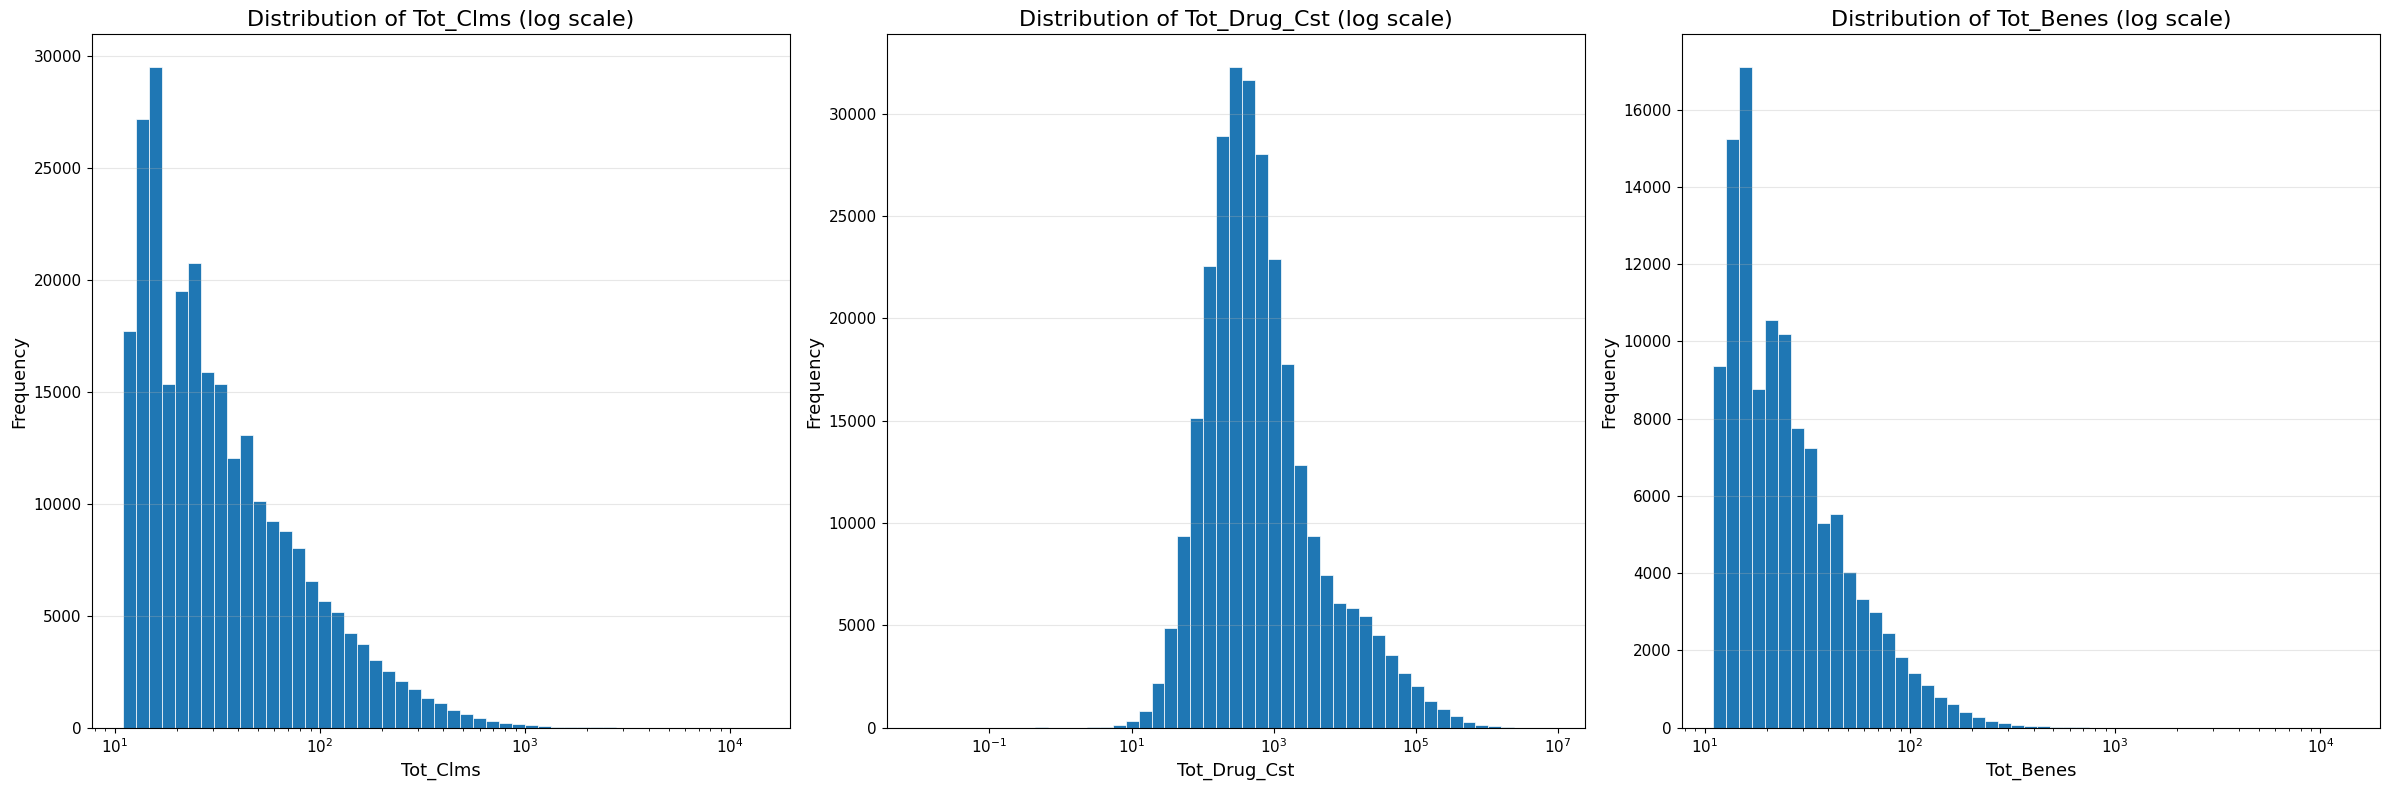

In [0]:
import matplotlib.pyplot as plt
import numpy as np

sample_df = df_bronze.select("Tot_Clms", "Tot_Drug_Cst", "Tot_Benes").sample(fraction=0.01, seed=42).toPandas()

fig, axes = plt.subplots(1, 3, figsize=(24, 8))

columns_to_plot = ["Tot_Clms", "Tot_Drug_Cst", "Tot_Benes"]
for ax, colname in zip(axes, columns_to_plot):
    data = sample_df[colname]
    data = data[data > 0]
    bins = np.logspace(np.log10(data.min()), np.log10(data.max()), 50)
    ax.hist(data, bins=bins, edgecolor="white", linewidth=0.5)
    ax.set_xscale("log")
    ax.set_title(f"Distribution of {colname} (log scale)", fontsize=16)
    ax.set_xlabel(colname, fontsize=13)
    ax.set_ylabel("Frequency", fontsize=13)
    ax.tick_params(axis="both", labelsize=11)
    ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

## Step 7: Consolidated Data Quality Findings

The exploratory data analysis conducted in Steps 1 to 6 is summarised below, forming the 
empirical basis for the cleansing decisions applied in the remainder of this notebook:

1. **Structure:** The dataset contains 28,023,892 rows and 22 columns, with no fully duplicated 
   records.
2. **Data types:** All columns carry appropriate data types on ingestion; no type correction is 
   required, with the exception that Prscrbr_NPI, while stored as an integer, is treated as a 
   categorical identifier rather than a measurable quantity for statistical purposes.
3. **Missing values:** Eight columns exhibit substantial missingness, concentrated in the GE65 
   (beneficiaries aged 65 and over) fields and Tot_Benes, ranging from 12.08% to 87.92% of 
   rows. Sample-row inspection confirms this missingness is not random: it corresponds directly 
   to the CMS-defined suppression flags (GE65_Sprsn_Flag, GE65_Bene_Sprsn_Flag), which 
   withhold beneficiary and claim counts of ten or fewer for privacy protection.
4. **Distribution:** The core volume and cost variables (Tot_Clms, Tot_Drug_Cst, Tot_Benes) are 
   strongly right-skewed and approximate a log-normal distribution, consistent with the 
   heterogeneous scale of prescribing activity across individual providers versus large 
   institutions. Values flagged by the interquartile-range rule are therefore interpreted as a 
   legitimate feature of the data rather than as errors.
5. **Categorical integrity:** Categorical columns exhibit plausible cardinality (for example, 61 
   distinct state codes, consistent with US states, the District of Columbia, and territories), 
   indicating no evidence of category-level data corruption.

## Step 8: String Consistency Check on Categorical Columns

Before finalising the cleansing logic, the categorical text columns are checked for whitespace 
and casing inconsistencies (for example, leading/trailing spaces or inconsistent capitalisation), 
which are common in large public datasets and would otherwise create false distinct categories 
in the Gold layer.

In [0]:
from pyspark.sql.functions import trim, length

check_cols = ["Prscrbr_City", "Prscrbr_State_Abrvtn", "Prscrbr_Type", "Prscrbr_Type_Src", "Brnd_Name", "Gnrc_Name"]

for c in check_cols:
    untrimmed_count = df_bronze.filter(length(col(c)) != length(trim(col(c)))).count()
    print(f"{c}: {untrimmed_count:,} rows with leading/trailing whitespace")

Prscrbr_City: 0 rows with leading/trailing whitespace
Prscrbr_State_Abrvtn: 0 rows with leading/trailing whitespace
Prscrbr_Type: 0 rows with leading/trailing whitespace
Prscrbr_Type_Src: 0 rows with leading/trailing whitespace
Brnd_Name: 0 rows with leading/trailing whitespace
Gnrc_Name: 0 rows with leading/trailing whitespace


## Step 9: Final Cleansing and Silver Layer Write

With no whitespace or casing inconsistencies present, the remaining cleansing steps address the 
two near-negligible missing-value cases in Prscrbr_State_FIPS (1 row) and Prscrbr_Type (17 rows), 
which are recoded as "Unknown" rather than dropped, since removing entire rows over a single 
missing categorical value would discard otherwise valid claims data. The CMS suppression flag 
codes are recoded into descriptive categorical labels, and the null values in the suppressed 
numeric columns (GE65_* fields and Tot_Benes) are deliberately preserved, as Step 3 established 
that these represent genuine privacy-driven suppression rather than data entry omissions. No 
rows are removed on the basis of the interquartile-range check, as Step 6 confirmed the flagged 
values reflect legitimate high-volume prescribing activity. The cleansed dataset is then 
persisted to the Silver container in Delta Lake format.

In [0]:
from pyspark.sql.functions import col, when, coalesce, lit

def recode_suppression_flag(flag_col):
    return (
        when(col(flag_col) == "*", "Direct Suppression")
        .when(col(flag_col) == "#", "Counter Suppression")
        .otherwise("Not Suppressed")
    )

df_silver = (
    df_bronze
    # Recode suppression flags into readable categorical labels
    .withColumn("GE65_Sprsn_Reason", recode_suppression_flag("GE65_Sprsn_Flag"))
    .withColumn("GE65_Bene_Sprsn_Reason", recode_suppression_flag("GE65_Bene_Sprsn_Flag"))
    .drop("GE65_Sprsn_Flag", "GE65_Bene_Sprsn_Flag")
    # Handle the two near-negligible missing categorical values
    .withColumn("Prscrbr_State_FIPS", coalesce(col("Prscrbr_State_FIPS"), lit("Unknown")))
    .withColumn("Prscrbr_Type", coalesce(col("Prscrbr_Type"), lit("Unknown")))
)

# Sanity checks
df_silver.groupBy("GE65_Sprsn_Reason").count().show(truncate=False)
df_silver.groupBy("GE65_Bene_Sprsn_Reason").count().show(truncate=False)
print(f"Prscrbr_State_FIPS nulls remaining: {df_silver.filter(col('Prscrbr_State_FIPS').isNull()).count()}")
print(f"Prscrbr_Type nulls remaining: {df_silver.filter(col('Prscrbr_Type').isNull()).count()}")

# Persist to Silver container in Delta format
silver_path = "abfss://silver@adlspharmaanalytics.dfs.core.windows.net/prescribers_cleansed"
df_silver.write.format("delta").mode("overwrite").save(silver_path)

print("Silver layer write complete.")
print(f"Rows written: {df_silver.count():,}")
print(f"Columns written: {len(df_silver.columns)}")

+-------------------+--------+
|GE65_Sprsn_Reason  |count   |
+-------------------+--------+
|Counter Suppression|9374102 |
|Direct Suppression |3089400 |
|Not Suppressed     |15560390|
+-------------------+--------+

+----------------------+--------+
|GE65_Bene_Sprsn_Reason|count   |
+----------------------+--------+
|Counter Suppression   |8294754 |
|Direct Suppression    |16343778|
|Not Suppressed        |3385360 |
+----------------------+--------+

Prscrbr_State_FIPS nulls remaining: 0
Prscrbr_Type nulls remaining: 0
Silver layer write complete.
Rows written: 28,023,892
Columns written: 22


In [0]:
silver_path = "abfss://silver@adlspharmaanalytics.dfs.core.windows.net/prescribers_cleansed"
df_silver_check = spark.read.format("delta").load(silver_path)

print(f"Rows: {df_silver_check.count():,}")
print(f"Columns: {len(df_silver_check.columns)}")
df_silver_check.printSchema()

display(df_silver_check.limit(20))

Rows: 28,023,892
Columns: 22
root
 |-- Prscrbr_NPI: integer (nullable = true)
 |-- Prscrbr_Last_Org_Name: string (nullable = true)
 |-- Prscrbr_First_Name: string (nullable = true)
 |-- Prscrbr_City: string (nullable = true)
 |-- Prscrbr_State_Abrvtn: string (nullable = true)
 |-- Prscrbr_State_FIPS: string (nullable = true)
 |-- Prscrbr_Type: string (nullable = true)
 |-- Prscrbr_Type_Src: string (nullable = true)
 |-- Brnd_Name: string (nullable = true)
 |-- Gnrc_Name: string (nullable = true)
 |-- Tot_Clms: integer (nullable = true)
 |-- Tot_30day_Fills: double (nullable = true)
 |-- Tot_Day_Suply: integer (nullable = true)
 |-- Tot_Drug_Cst: double (nullable = true)
 |-- Tot_Benes: integer (nullable = true)
 |-- GE65_Tot_Clms: integer (nullable = true)
 |-- GE65_Tot_30day_Fills: double (nullable = true)
 |-- GE65_Tot_Drug_Cst: double (nullable = true)
 |-- GE65_Tot_Day_Suply: integer (nullable = true)
 |-- GE65_Tot_Benes: integer (nullable = true)
 |-- GE65_Sprsn_Reason: string (nu

Prscrbr_NPI,Prscrbr_Last_Org_Name,Prscrbr_First_Name,Prscrbr_City,Prscrbr_State_Abrvtn,Prscrbr_State_FIPS,Prscrbr_Type,Prscrbr_Type_Src,Brnd_Name,Gnrc_Name,Tot_Clms,Tot_30day_Fills,Tot_Day_Suply,Tot_Drug_Cst,Tot_Benes,GE65_Tot_Clms,GE65_Tot_30day_Fills,GE65_Tot_Drug_Cst,GE65_Tot_Day_Suply,GE65_Tot_Benes,GE65_Sprsn_Reason,GE65_Bene_Sprsn_Reason
1194780320,Saky,Marie-Therese,Oakhurst,NJ,34,Endocrinology,Claim-Specialty,Glimepiride,Glimepiride,108,259.8,7794,1135.6,23,108,259.8,1135.6,7794,23,Not Suppressed,Not Suppressed
1194780320,Saky,Marie-Therese,Oakhurst,NJ,34,Endocrinology,Claim-Specialty,Humalog,Insulin Lispro,24,52.1,1540,5080.12,null,24,52.1,5080.12,1540,null,Not Suppressed,Direct Suppression
1194780320,Saky,Marie-Therese,Oakhurst,NJ,34,Endocrinology,Claim-Specialty,Humalog Kwikpen U-100,Insulin Lispro,115,305.4,9144,24940.71,39,null,null,null,null,null,Counter Suppression,Counter Suppression
1194780320,Saky,Marie-Therese,Oakhurst,NJ,34,Endocrinology,Claim-Specialty,Humalog Mix 75-25 Kwikpen,Insulin Lispro Protamin/Lispro,11,12.6,350,1873.98,null,11,12.6,1873.98,350,null,Not Suppressed,Direct Suppression
1194780320,Saky,Marie-Therese,Oakhurst,NJ,34,Endocrinology,Claim-Specialty,Hydrocortisone,Hydrocortisone,21,35.0,1049,901.91,null,null,null,null,null,null,Direct Suppression,Direct Suppression
1194780320,Saky,Marie-Therese,Oakhurst,NJ,34,Endocrinology,Claim-Specialty,Insulin Lispro Kwikpen U-100,Insulin Lispro,17,39.0,1143,3247.19,null,null,null,null,null,null,Direct Suppression,Direct Suppression
1194780320,Saky,Marie-Therese,Oakhurst,NJ,34,Endocrinology,Claim-Specialty,Januvia,Sitagliptin Phosphate,71,149.6,4461,67634.31,17,71,149.6,67634.31,4461,17,Not Suppressed,Not Suppressed
1194780320,Saky,Marie-Therese,Oakhurst,NJ,34,Endocrinology,Claim-Specialty,Jardiance,Empagliflozin,21,43.0,1290,24141.16,null,21,43.0,24141.16,1290,null,Not Suppressed,Direct Suppression
1194780320,Saky,Marie-Therese,Oakhurst,NJ,34,Endocrinology,Claim-Specialty,Lantus Solostar,"Insulin Glargine,hum.Rec.Anlog",130,340.6,10070,16297.75,49,null,null,null,null,null,Counter Suppression,Counter Suppression
1194780320,Saky,Marie-Therese,Oakhurst,NJ,34,Endocrinology,Claim-Specialty,Levemir,Insulin Detemir,24,39.2,1046,4965.14,null,null,null,null,null,null,Counter Suppression,Direct Suppression
